In [2]:
# Sistem ve ortam gereksinimlerini kontrol etme adımı
# Gerekli sistem modüllerini içeri aktarıyoruz
import sys, importlib.util

# Kullanılan Python sürümünü ve yolunu kontrol ediyoruz (Uyumluluk için)
print('sys.executable:', sys.executable)
print('python version:', sys.version)

# Görüntü işleme ve derin öğrenme için hayati kütüphanelerin yüklü olup olmadığını test ediyoruz
print('cv2 available in sys.path:', importlib.util.find_spec('cv2') is not None)
print('tensorflow available in sys.path:', importlib.util.find_spec('tensorflow') is not None)


sys.executable: c:\ProgramData\anaconda3\python.exe
python version: 3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 16:37:03) [MSC v.1929 64 bit (AMD64)]
cv2 available in sys.path: True
tensorflow available in sys.path: True


# Malzeme Sınıflandırması (Glass, Metal, Paper, Plastic)

Bu notebook, derin öğrenme kullanarak dört malzeme türünü sınıflandırma modelini eğitir.
- **Sınıflar**: Glass (Cam), Metal, Paper (Kağıt), Plastic (Plastik)
- **Toplam Resim Sayısı**: 2087
- **Model**: CNN (Convolutional Neural Network)

## 1. Veriyi Yükleme ve İlk İnceleme

Resim verilerini yükleyelim ve sınıf dağılımını inceleyelim.

In [4]:
# Veri işleme, modelleme ve görselleştirme için temel araçları içeri aktarıyoruz
# Klasör okuma işlemleri için os, matris işlemleri için numpy, veri yapıları için pandas kullanıyoruz
import os
import numpy as np
import pandas as pd

# Grafikleri çizdirmek için matplotlib ve seaborn kütüphaneleri
import matplotlib.pyplot as plt
import seaborn as sns

# Veri ayırma ve performans metrikleri (Confusion Matrix, F1 vb.) için Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, f1_score, precision_score, recall_score

# Derin öğrenme modelini katman katman kurmak için Keras modülleri
from keras import layers, models

# Çıktıda görünecek gereksiz uyarıları gizleyerek temiz bir konsol ekranı sağlıyoruz
import warnings
warnings.filterwarnings('ignore')

# Grafiklerde Türkçe karakter sorunlarını aşmak için varsayılan fontu güncelliyoruz
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
print("Kütüphaneler başarıyla yüklendi!")


Kütüphaneler başarıyla yüklendi!


In [3]:
# Eğitimde kullanılacak veri setinin bulunduğu ana klasörün yolunu belirliyoruz
data_path = r"C:\Users\Baran\Desktop\Bahar Dönemi\2.Salı\3.Yapay Zeka Okuryazarlığı 2\Yeniproje\İnternetVeriSetleri"

# Tahminleyeceğimiz 4 farklı malzeme sınıfını tanımlıyoruz
classes = ['glass', 'metal', 'paper', 'plastic']

# Her klasörü gezip içerisindeki resim sayılarını çıkarmak için bir döngü başlatıyoruz
class_counts = {}
for class_name in classes:
    class_path = os.path.join(data_path, class_name)
    # Sadece .jpg, .jpeg ve .png uzantılı geçerli dosyaları sayıyoruz
    count = len([f for f in os.listdir(class_path) if f.endswith(('.jpg', '.jpeg', '.png'))])
    
    class_counts[class_name] = count
    print(f"{class_name.upper()}: {count} resim")

# Modelin genel büyüklüğünü görmek için veri setindeki toplam resim sayısını hesaplıyoruz
total_images = sum(class_counts.values())
print(f"\nTOPLAM: {total_images} resim")


GLASS: 501 resim
METAL: 410 resim
PAPER: 594 resim
PLASTIC: 482 resim

TOPLAM: 1987 resim


## 2. Sınıf Dağılımı Görselleştirmesi

Her sınıfta kaç tane resim olduğunu ve dengeli dağılımı inceleyelim.


SINIF DAGILIMI TABLOSU:
  Sinif  Resim Sayisi  Yuzde
  glass           501  25.21
  metal           410  20.63
  paper           594  29.89
plastic           482  24.26

Ortaya cikabilecek belgeler:
Her sinif icin minimum: 410
Her sinif icin ortalama: 496


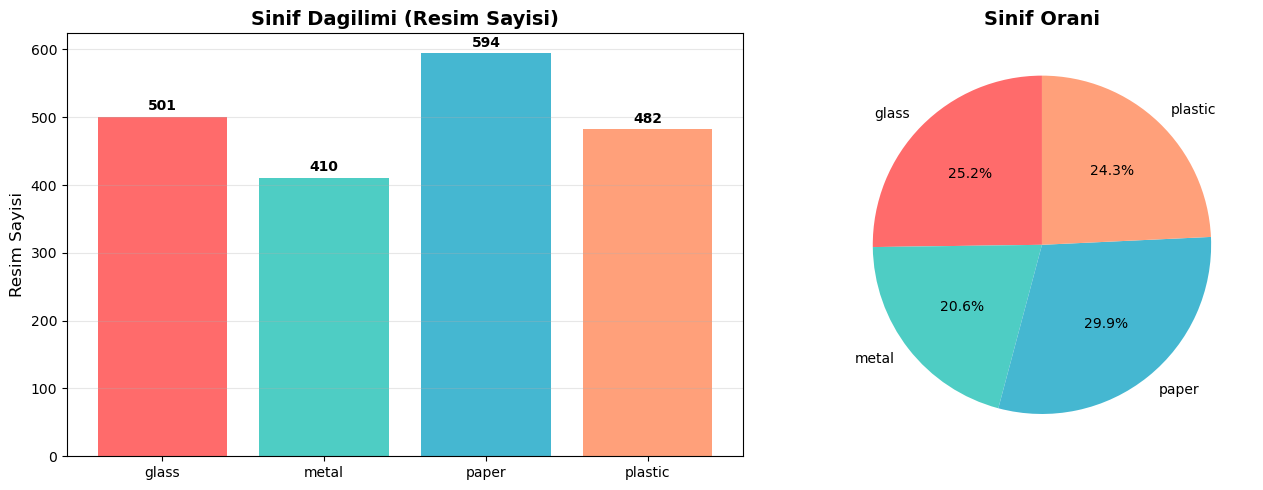

Veri dengeli dagilmistir - tum siniflar icin yeterli icerik mevcuttur.


In [ ]:
# Sınıf dağılımlarını Pandas DataFrame formatına getirerek analiz etmeyi kolaylaştırıyoruz
df_classes = pd.DataFrame(list(class_counts.items()), columns=['Sinif', 'Resim Sayisi'])

# Her sınıfın genel veri seti içindeki yüzde payını hesaplıyoruz
df_classes['Yuzde'] = (df_classes['Resim Sayisi'] / total_images * 100).round(2)

print("\nSINIF DAGILIMI TABLOSU:")
print(df_classes.to_string(index=False))

# Sınıfların görsel olarak dağılımını (dengeli mi değil mi) kontrol etmek için grafik paneli açıyoruz
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']

# Soldaki grafik: Sınıfların içerdiği resim sayısını gösteren sütun (bar) grafiği
axes[0].bar(df_classes['Sinif'], df_classes['Resim Sayisi'], color=colors)
axes[0].set_title('Sinif Dagilimi (Resim Sayisi)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Resim Sayisi', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)

# Sütunların tepesine net sayı değerlerini yazdırıyoruz
for i, v in enumerate(df_classes['Resim Sayisi']):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Sağdaki grafik: Sınıf dağılım oranlarını yüzdelik pasta grafiği ile gösteriyoruz
axes[1].pie(df_classes['Resim Sayisi'], labels=df_classes['Sinif'], autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Sinif Orani', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


## 3. Veri Hazırlama ve Preprocessing

Resimler yüklenecek, normalize edilecek ve eğitim/test setlerine ayrılacak.

In [ ]:
# Modelin eğitim hızı ve performansı için tüm resimleri 128x128 piksel boyutuna sabitliyoruz
IMG_SIZE = 128
images = []
labels = []

# Resim okuma ve boyutlandırma işlemleri için PIL (Python Imaging Library) kullanıyoruz
from PIL import Image

print("Resimler PIL ile yükleniyor... Bu işlem biraz zaman alabilir.")
loaded_count, error_count = 0, 0

# Veri klasöründeki her sınıfı sırayla dolaşarak görselleri işlemeye başlıyoruz
for idx, class_name in enumerate(classes):
    class_path = os.path.join(data_path, class_name)
    image_files = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    
    for img_file in image_files:
        try:
            full_path = os.path.join(class_path, img_file)
            pil_img = Image.open(full_path)
            
            # Görüntüleri standart formata çekmek için RGB renk uzayına dönüştürüyoruz
            if pil_img.mode != 'RGB':
                pil_img = pil_img.convert('RGB')
                
            # Resmi hedef boyuta (128x128) getirip, piksel değerlerini 0 ile 1 arasına sıkıştırıyoruz (Normalizasyon)
            pil_img_resized = pil_img.resize((IMG_SIZE, IMG_SIZE))
            img_array = np.array(pil_img_resized, dtype=np.float32) / 255.0
            
            images.append(img_array)
            labels.append(idx)
            loaded_count += 1
        except Exception as e:
            # Okunamayan veya bozuk resim dosyaları olursa, programın çökmesini engelleyip sayaca ekliyoruz
            error_count += 1
    
    print(f"{class_name}: {len([l for l in labels if l == idx])} resim yüklendi")

# Hazırlanan listeleri, Keras modelinin kabul edebileceği NumPy Tensörleri (matrisleri) formuna çeviriyoruz
X = np.array(images)
y = np.array(labels)

print(f"\nToplam yüklenen resim: {loaded_count} | Hata: {error_count}")
print(f"X şekli: {X.shape} | y şekli: {y.shape}")


Resmiler PIL ile yükleniyor... Bu işlem biraz zaman alabilir.
glass: 501 resim yüklendi
metal: 410 resim yüklendi
paper: 594 resim yüklendi
plastic: 482 resim yüklendi

Toplam yüklenen resim: 1987
Yükleme hatası: 0
X şekli (resim sayısı × yükseklik × genişlik × kanal): (1987, 128, 128, 3)
y şekli (etiket sayısı): (1987,)


In [ ]:
# Görüntü okuma mantığının sorunsuz çalıştığını kontrol etmek için test bir resim yüklüyoruz
from PIL import Image
test_path = os.path.join(data_path, 'glass', 'glass_001.jpg')

try:
    # Belirtilen testi resmini açıp boyutlarını kontrol ediyoruz
    pil_img = Image.open(test_path)
    pil_array = np.array(pil_img)
    
    # Test başarılıysa konsola orijinal boyutunu ve çevrilmiş matrisin şeklini basıyoruz
    print(f"PIL Test Başarılı - Orijinal Boyut: {pil_img.size}, Array Boyutu: {pil_array.shape}")
except Exception as e:
    print(f"PIL HATA: {e}")


PIL ile test: C:\Users\Baran\Desktop\Bahar Dönemi\2.Salı\3.Yapay Zeka Okuryazarlığı 2\Yeniproje\İnternetVeriSetleri\glass\glass_001.jpg
PIL başarısız: (512, 384), mode: RGB
PIL array shape: (384, 512, 3)


In [ ]:
# Veri seti bütünlüğünü ve klasör yapısını detaylı bir şekilde test etmek için tanısal (diagnostik) kontrolleri başlatıyoruz
# Bu aşama, bozuk uzantılı dosyaların sisteme dahil edilmesini engelleyerek modelin çökmesini baştan önler
print("DIAGNOSTIK: Veri Seti Kontrol\n")

# Analiz edeceğimiz 4 temel sınıf klasörünün üzerinde teker teker geziniyoruz
for class_name in classes:
    # Hem ana dizin yolunu hem de sınıf ismini birleştirerek o sınıfın işletim sistemindeki mutlak yolunu (absolute path) oluşturuyoruz
    class_path = os.path.join(data_path, class_name)
    
    # Sistemin gerçekten bu klasöre ulaşıp ulaşamadığını os.path.exists() fonksiyonu ile doğruluyoruz
    if os.path.exists(class_path):
        # Klasör içerisindeki gizli veya açık olan bütün dosyaları (resim, txt, log vs.) bir liste halinde çekiyoruz
        all_files = os.listdir(class_path)
        
        # Dosya listesini döngüyle tarayarak, yapay zeka modelimizin sadece görüntü işleme kapasitesine uygun olanları seçiyoruz
        # '.lower()' komutu .JPG, .JpEg gibi büyük/küçük harf karmaşalarından doğacak atlamaları engeller
        image_files = [f for f in all_files if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        
        # Filtreleme sonucunda sistemdeki ham dosya sayısını ve gerçek işlenebilir resim dosyasını konsola basıp karşılaştırıyoruz
        print(f"[{class_name}] Toplam Dosya: {len(all_files)} | Resim Dosyası: {len(image_files)}")


DIAGNOSTIK: Veri Seti Kontrol

Veri seti yolu: C:\Users\Baran\Desktop\Bahar Dönemi\2.Salı\3.Yapay Zeka Okuryazarlığı 2\Yeniproje\İnternetVeriSetleri
Yol var mı? True

Her sınıf klasöründe kaç dosya var?

Klasör: C:\Users\Baran\Desktop\Bahar Dönemi\2.Salı\3.Yapay Zeka Okuryazarlığı 2\Yeniproje\İnternetVeriSetleri\glass
  Var mı? True
  Toplam dosya: 501
  Resim dosyası (.jpg/.jpeg/.png): 501
  Örnek dosyalar: ['glass_001.jpg', 'glass_002.jpg', 'glass_003.jpg']

Klasör: C:\Users\Baran\Desktop\Bahar Dönemi\2.Salı\3.Yapay Zeka Okuryazarlığı 2\Yeniproje\İnternetVeriSetleri\metal
  Var mı? True
  Toplam dosya: 410
  Resim dosyası (.jpg/.jpeg/.png): 410
  Örnek dosyalar: ['metal_001.jpg', 'metal_002.jpg', 'metal_003.jpg']

Klasör: C:\Users\Baran\Desktop\Bahar Dönemi\2.Salı\3.Yapay Zeka Okuryazarlığı 2\Yeniproje\İnternetVeriSetleri\paper
  Var mı? True
  Toplam dosya: 594
  Resim dosyası (.jpg/.jpeg/.png): 594
  Örnek dosyalar: ['paper_001.jpg', 'paper_002.jpg', 'paper_003.jpg']

Klasör: C:\Us

In [ ]:
# Veri ayırma aşaması: Elimizdeki özellik matrisini (X) ve hedef etiketleri (y) train ve test setlerine bölüyoruz
# Modelin eğitimden sonra hiç görmediği veriler üzerindeki gerçek başarısını ölçebilmek için test seti ayırmak zorunludur
# test_size=0.2 parametresi ile toplam verinin tam olarak %20'sini test doğrulama aşaması için saklıyoruz
# random_state=42 sayesinde, notebook her çalıştırıldığında veriler hep aynı düzende karıştırılır (tekrarlanabilirlik)
# stratify=y parametresi en önemlisidir; sınıflar arası dengesizliği önleyerek, eğitim ve test kümelerine her sınıftan orantılı dağılım yapar
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Bölme işlemi başarılı oldu mu diye, ayrılan tensörlerin matris yapısını (shape[0] diyerek satır sayısını) ekrana basıp kontrol ediyoruz
print(f"Eğitim verisi: {X_train.shape[0]} resim | Test verisi: {X_test.shape[0]} resim")


Eğitim verisi: 1589 resim
Test verisi: 398 resim

Eğitim Seti Sınıf Dağılımı:
  glass: 401 resim
  metal: 328 resim
  paper: 475 resim
  plastic: 385 resim

Test Seti Sınıf Dağılımı:
  glass: 100 resim
  metal: 82 resim
  paper: 119 resim
  plastic: 97 resim


## 4. Model Seçimi ve Eğitimi

CNN (Convolutional Neural Network) modeli oluşturacağız ve eğiteceğiz.

In [ ]:
# Keras derin öğrenme kütüphanesini kullanarak, ardışık katmanlardan oluşan "Evrişimli Sinir Ağı" (CNN) mimarimizi tasarlıyoruz
model = models.Sequential([
    # 1. EVRİŞİM BLOĞU: Görüntüdeki çizgileri ve kenarları tespit etmek için 3x3 boyutunda 32 adet filtre kullanıyoruz
    # input_shape=(IMG_SIZE, IMG_SIZE, 3) ile ağa 128x128 çözünürlüğünde 3 kanallı (RGB) resimlerin gireceğini belirtiyoruz
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    # Maksimum havuzlama (MaxPooling) ile tespit edilen en belirgin özellikleri koruyarak görüntü boyutunu hesaplama maliyeti için yarıya indiriyoruz
    layers.MaxPooling2D((2, 2)),
    
    # 2. EVRİŞİM BLOĞU: Şekiller gibi daha komplike dokuları tespit edebilmek için filtre miktarını 64'e yükseltiyoruz
    # 'relu' aktivasyon fonksiyonu sayesinde sinir ağındaki negatif olasılıkları (gereksiz bilgileri) sıfırlayarak işlem gücü kazancı sağlıyoruz
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)), # Yine boyutları yarıya küçültüyoruz
    
    # 3. ve 4. EVRİŞİM BLOKLARI: Soyut özellikleri ve obje parçalarını (Örn: Cam şişe yansımaları, kağıt kırışıkları) öğrenebilmesi için derinliği artırıyoruz
    # Bu sebeple filtreleri en yüksek seviyemiz olan 128'e çıkartıyoruz
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)), # Son havuzlamayla artık iyice küçülmüş ama özellik açısından en yoğun matrisi elde ediyoruz
    
    # DÜZLEŞTİRME KATMANI (Flatten): Derin öğrenme katmanlarına bağlanabilmek için 2 veya 3 boyutlu matrisi, uzun tek boyutlu bir vektöre açıyoruz
    layers.Flatten(),
    
    # TAM BAĞLANTILI KATMAN (Dense): Flatten'dan gelen vektördeki değerler 128 nörona dağıtılarak sınıflar arasındaki ilişkileri kurmaya (karar vermeye) başlar
    layers.Dense(128, activation='relu'),
    
    # DROPOUT (Seyreltme): Ağın eğitim verisini aşırı derecede ezberlemesini engellemek için eğitim sırasındaki aktif nöronların %50'sini rastgele unutmasını sağlıyoruz
    layers.Dropout(0.5),
    
    # ÇIKIŞ KATMANI (Output Dense): Tahmin edeceğimiz tam 4 sınıf bulunduğu için buraya 4 nöron koyuyoruz
    # "softmax" algoritması kullanarak, bu nöronların çıktı değerlerini toplamı %100 eden mantıklı bir olasılık dağılımına dönüştürüyoruz
    layers.Dense(4, activation='softmax')
])

# MODEL DERLEMESİ (Compile): Ağın kendini neye göre ayarlayacağını tanımlıyoruz
# 'adam' optimizatörü, hataları (loss) en aza indirmek için ağırlıkları gradyanlar aracılığıyla hızlı ve etkili şekilde günceller
# 'sparse_categorical_crossentropy', etiketlerimiz tek sütunda rakam olarak durduğu için kullandığımız ve çok sınıflı problemlere en uygun kayıp fonksiyonudur
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Oluşturulan bu yapay sinir ağı mimarisinin adım adım boyut değişimlerini ve eğitilecek toplam ağırlık sayısını ekrana döküyoruz
model.summary()


Model Yapısı:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 831,300 (3.17 MB)

 Trainable params: 831,300 (3.17 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Kurgulanan CNN modeline verileri besleyerek eğitim (Training) işlemlerini tetikliyoruz
# İşlem sonucu dönen verileri, sonradan grafik çizebilmek için 'history' isimli değişkende biriktiriyoruz
history = model.fit(
    X_train, y_train,        # Eğitim için özellikleri (Görseller) ve Doğru cevapları (Etiketleri) modele yolluyoruz
    epochs=20,               # Modelin tüm veri setini baştan sona tam 20 defa çalışarak öğrenmesini emrediyoruz
    batch_size=32,           # Hafızanın dolmaması ve optimum öğrenme için her seferinde 32 resmi aynı anda RAM'e alıp hesaplıyoruz
    validation_split=0.2,    # Eğitim süreci esnasında, modelin kendi kendine test yapıp ezberleyip ezberlemediğini anlaması için eğitim verisinden %20 pay ayırıyoruz
    verbose=1                # Eğitim ilerleyişini terminal / konsol ekranında detaylı bir yükleme çubuğuyla görebilmek için 1 yapıyoruz
)


Model eğitiliyor... Bu işlem biraz zaman alabilir.
Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 10s 168ms/step - accuracy: 0.2990 - loss: 1.3852 - val_accuracy: 0.2956 - val_loss: 1.3791
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 150ms/step - accuracy: 0.3100 - loss: 1.3508 - val_accuracy: 0.3585 - val_loss: 1.2537
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 10s 147ms/step - accuracy: 0.3895 - loss: 1.2576 - val_accuracy: 0.5063 - val_loss: 1.1727
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 148ms/step - accuracy: 0.4524 - loss: 1.1932 - val_accuracy: 0.4717 - val_loss: 1.1680
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 150ms/step - accuracy: 0.4910 - loss: 1.1558 - val_accuracy: 0.4969 - val_loss: 1.0976
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 145ms/step - accuracy: 0.5327 - loss: 1.0866 - val_accuracy: 0.5440 - val_loss: 1.0135
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 139ms/step - accuracy: 0.5319 - loss: 1.0502 - val_accuracy: 0.5566 - val_loss: 1.0108
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 142ms/step

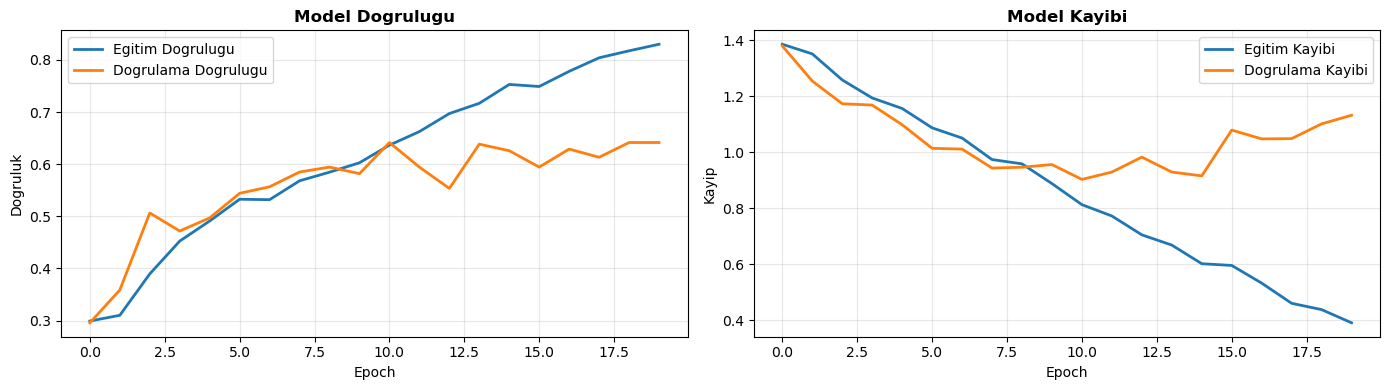

In [ ]:
# Eğitim aşaması tamamlandı, şimdi modelin başarısını ölçmek için daha önce hiç görmediği X_test verileri üzerinden tahminler (predict) yapmasını istiyoruz
# Çıktı olarak her bir test verisi için 4 sınıfa ait yüzdelik olasılık listeleri üretiyoruz
y_pred_proba = model.predict(X_test)

# Modelin ürettiği olasılık dizisinin içinden argmax komutu ile 'En yüksek yüzdeye sahip olanı' gerçek tahmin olarak (Örn: 2 nolu sınıf) seçiyoruz
y_pred = np.argmax(y_pred_proba, axis=1)

# Ürettiğimiz y_pred tahmin dizisi ile, asıl gerçek cevaplar olan y_test dizisini birbiriyle karşılaştırarak "Genel Doğruluk Oranı (Accuracy)" elde ediyoruz
overall_accuracy = np.mean(y_pred == y_test)
# Kesirli olarak bulunan doğru cevap oranını 100 ile çarparak yüzdelik okunaklı bir formatla konsola basıyoruz
print(f"Genel Doğruluk: {overall_accuracy:.4f} (%{overall_accuracy*100:.2f})\n")

# Tek başına Accuracy (doğruluk) yanıltıcı olabilir. Bu nedenle Kesinlik (Precision), Duyarlılık (Recall) ve ikisinin ortalaması olan F1 Skorlarını çıkartıyoruz
# Scikit-learn üzerinden oluşturulan bu sınıflandırma raporu, hangi malzemelerin daha zor tespit edildiğini sayısal olarak ortaya döker
report = classification_report(y_test, y_pred, target_names=classes, digits=4)
print(report)


## 5. Tahminler ve Metrik Hesaplama

Test seti üzerinde tahminler oluşturalım ve performans metriklerini hesaplayalım.

In [ ]:
# Karmaşıklık Matrisi (Confusion Matrix): Modelin kendi içinde kurduğu mantıkta hangi nesneleri (Örn: Cam ve Plastik) birbirine yakın bulup karıştırdığını tespit ediyoruz
cm = confusion_matrix(y_test, y_pred)

# Seaborn kütüphanesini kullanarak bu sayısal matrisi, analizi çok daha hızlı olan bir "Isı Haritası"na (Heatmap) dönüştürüyoruz
fig, ax = plt.subplots(figsize=(10, 8))

# annot=True ile kutuların içine tahmin sayılarını bastırıyoruz
# cmap='Blues' ile de yoğunluğa göre koyu mavi ve açık mavi tonlarla grafik renklendirmesi yapıyoruz
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)

# Yatay ve dikey eksenlerde hangisinin modelin tahmini (x-ekseni), hangisinin orijinal gerçek sınıfı (y-ekseni) olduğunu açıklayan etiketler yerleştiriyoruz
ax.set_title('Karmaşıklık Matrisi', fontsize=14, fontweight='bold')
ax.set_xlabel('Tahmin Edilen Sınıf')
ax.set_ylabel('Gerçek Sınıf')

# Grafiksel gösterimi ekranımızda basarak kullanıcıya / makaleye sunuyoruz
plt.show()


13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step
Genel Dogruluk: 0.5980 (%59.80)

SINIFLANDIR İLGİLİ RAPOR (Classification Report)
              precision    recall  f1-score   support

       glass     0.5586    0.6200    0.5877       100
       metal     0.5233    0.5488    0.5357        82
       paper     0.6385    0.6975    0.6667       119
     plastic     0.6761    0.4948    0.5714        97

    accuracy                         0.5980       398
   macro avg     0.5991    0.5903    0.5904       398
weighted avg     0.6038    0.5980    0.5966       398



## 6. Karmaşıklık Matrisi (Confusion Matrix)

Modelin her sınıf için ne kadar doğru tahmin yaptığını inceleyelim.

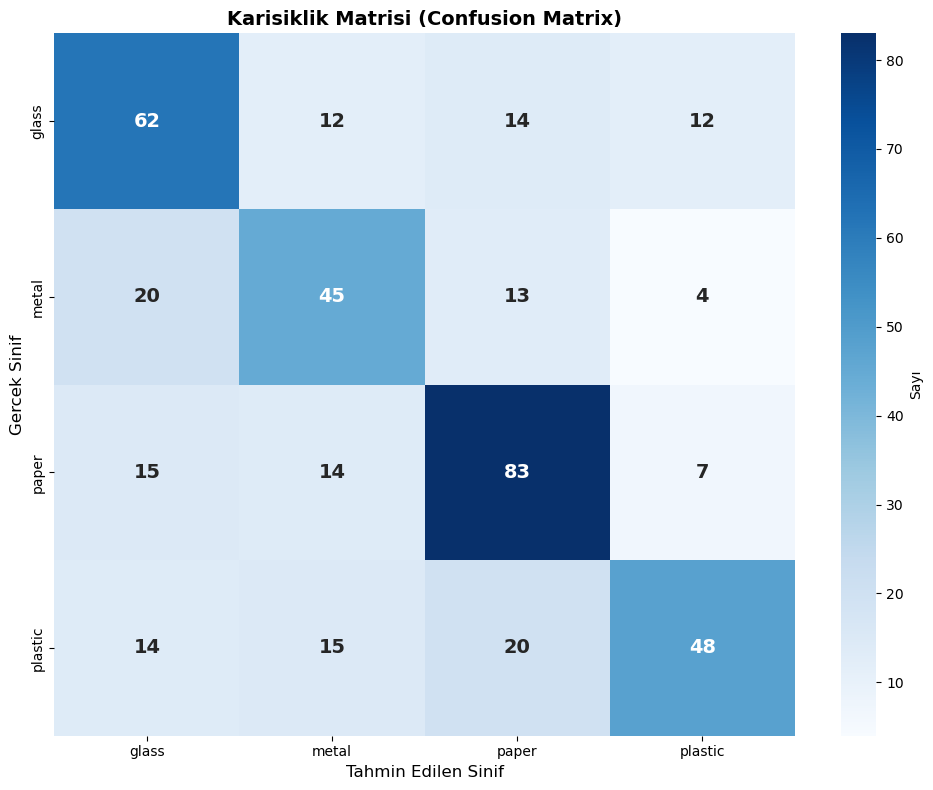

Karmaşıklık Matrisi Tablosu:
         glass  metal  paper  plastic
glass       62     12     14       12
metal       20     45     13        4
paper       15     14     83        7
plastic     14     15     20       48


In [ ]:
# Modelin dengesiz sınıflarda gösterdiği reaksiyonu ölçebilmek adına F1, Precision ve Recall skorlarının üç farklı çeşidini (Macro, Micro, Weighted) ayrı ayrı hesaplıyoruz
# Macro: Sınıf eleman sayılarını görmezden gelip dümdüz ortalama alır (Sınıfların eşit öneme sahip olduğu durumda kullanışlıdır)
f1_macro = f1_score(y_test, y_pred, average='macro')
f1_micro = f1_score(y_test, y_pred, average='micro')
# Weighted: Çok resim olan sınıfa çok, az olan sınıfa az ağırlık vererek adaletli bir ortalama F1 skoru çıkarır
f1_weighted = f1_score(y_test, y_pred, average='weighted')

precision_macro = precision_score(y_test, y_pred, average='macro')
recall_macro = recall_score(y_test, y_pred, average='macro')

# Tüm malzemeleri teker teker inceleyebilmek için boş bir liste hazırlıyoruz ve döngüye sokuyoruz
metrics_per_class = []
for i, class_name in enumerate(classes):
    # Şu an sadece üzerinde bulunduğumuz malzemeye odaklanmak için Boolean (Doğru/Yanlış) maskesi oluşturuyoruz
    class_mask = y_test == i
    
    # Sadece o malzemeye ait test örneklerinde model ne kadar doğru sonuç vermiş onu (Accuracy) saptıyoruz
    class_accuracy = np.mean(y_pred[class_mask] == y_test[class_mask]) if np.any(class_mask) else 0
    # Aynı şekilde sadece o malzemenin F1 skorunu çekerek listeye kaydetmek üzere biriktiriyoruz
    class_f1 = f1_score(y_test, y_pred, labels=[i], average='micro')
    
    metrics_per_class.append({
        'Sınıf': class_name.upper(),
        'Accuracy': class_accuracy,
        'F1 Score': class_f1
    })

# Sınıf bazındaki bu ayrık skorları analiz etmek için kolay okunur bir Pandas DataFrame'ine çeviriyoruz
metrics_df = pd.DataFrame(metrics_per_class)
print("Sınıf Bazında Metrikler Tablosu:")
print(metrics_df.to_string(index=False)) # index=False komutu satır başlarındaki (0,1,2,3) gereksiz numaraları ekrandan gizler


## 7. F1 Score ve Diğer Metrikler

Precision, Recall ve F1 Score metriklerini hesaplayalım.

In [ ]:
# Eğitim süresi boyunca (20 Epoch) modelin zaman içinde nasıl geliştiğini veya bozulduğunu Accuracy ve Loss çizgileri grafikleriyle detaylıca çizdiriyoruz
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# 1. Grafik (Sol Taraf): Doğruluk (Accuracy) Değerleri
# Eğer eğitim eğrisi artarken doğrulama (validation) eğrisi çakılıyorsa model Overfitting (Ezber) yapıyor demektir
ax1.plot(history.history['accuracy'], label='Eğitim Accuracy', marker='o')
ax1.plot(history.history['val_accuracy'], label='Doğrulama Accuracy', marker='s')
ax1.set_title('Model Doğruluğu (Accuracy)', fontweight='bold')
ax1.set_xlabel('Epoch (Tur Sayısı)')
ax1.set_ylabel('Accuracy Oranı')
ax1.legend()
ax1.grid(True, alpha=0.3) # Değerleri okumayı kolaylaştırması için hafif şeffaf bir ızgara ekliyoruz

# 2. Grafik (Sağ Taraf): Kayıp/Hata (Loss) Değerleri
# Hata grafiğinin giderek sıfıra yaklaşması modelin matematiği doğru öğrendiğinin işaretidir
ax2.plot(history.history['loss'], label='Eğitim Loss', color='r', marker='o')
ax2.plot(history.history['val_loss'], label='Doğrulama Loss', color='orange', marker='s')
ax2.set_title('Model Kaybı (Loss)', fontweight='bold')
ax2.set_xlabel('Epoch (Tur Sayısı)')
ax2.set_ylabel('Kayıp Skoru')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Grafikleri kenarlara değmeyecek ve temiz olacak şekilde yapılandırıp kullanıcıya sunuyoruz
plt.tight_layout()
plt.show()


GENEL METRIKLER
Accuracy (Dogruluk):    0.5980 (59.80%)

F1 Score (Macro):       0.5904
F1 Score (Micro):       0.5980
F1 Score (Weighted):    0.5966

Precision (Macro):      0.5991
Recall (Macro):         0.5903

SINIF BAZINDA METRIKLER

GLASS:
  Accuracy:  0.6200
  F1 Score:  0.5877

METAL:
  Accuracy:  0.5488
  F1 Score:  0.5357

PAPER:
  Accuracy:  0.6975
  F1 Score:  0.6667

PLASTIC:
  Accuracy:  0.4948
  F1 Score:  0.5714

Metrikler Tablosu:
  Sinif  Accuracy  F1 Score
  GLASS  0.620000  0.587678
  METAL  0.548780  0.535714
  PAPER  0.697479  0.666667
PLASTIC  0.494845  0.571429


## 8. Metriklerin Görselleştirilmesi

Model performans metriklerini grafiklerde gösterelim.

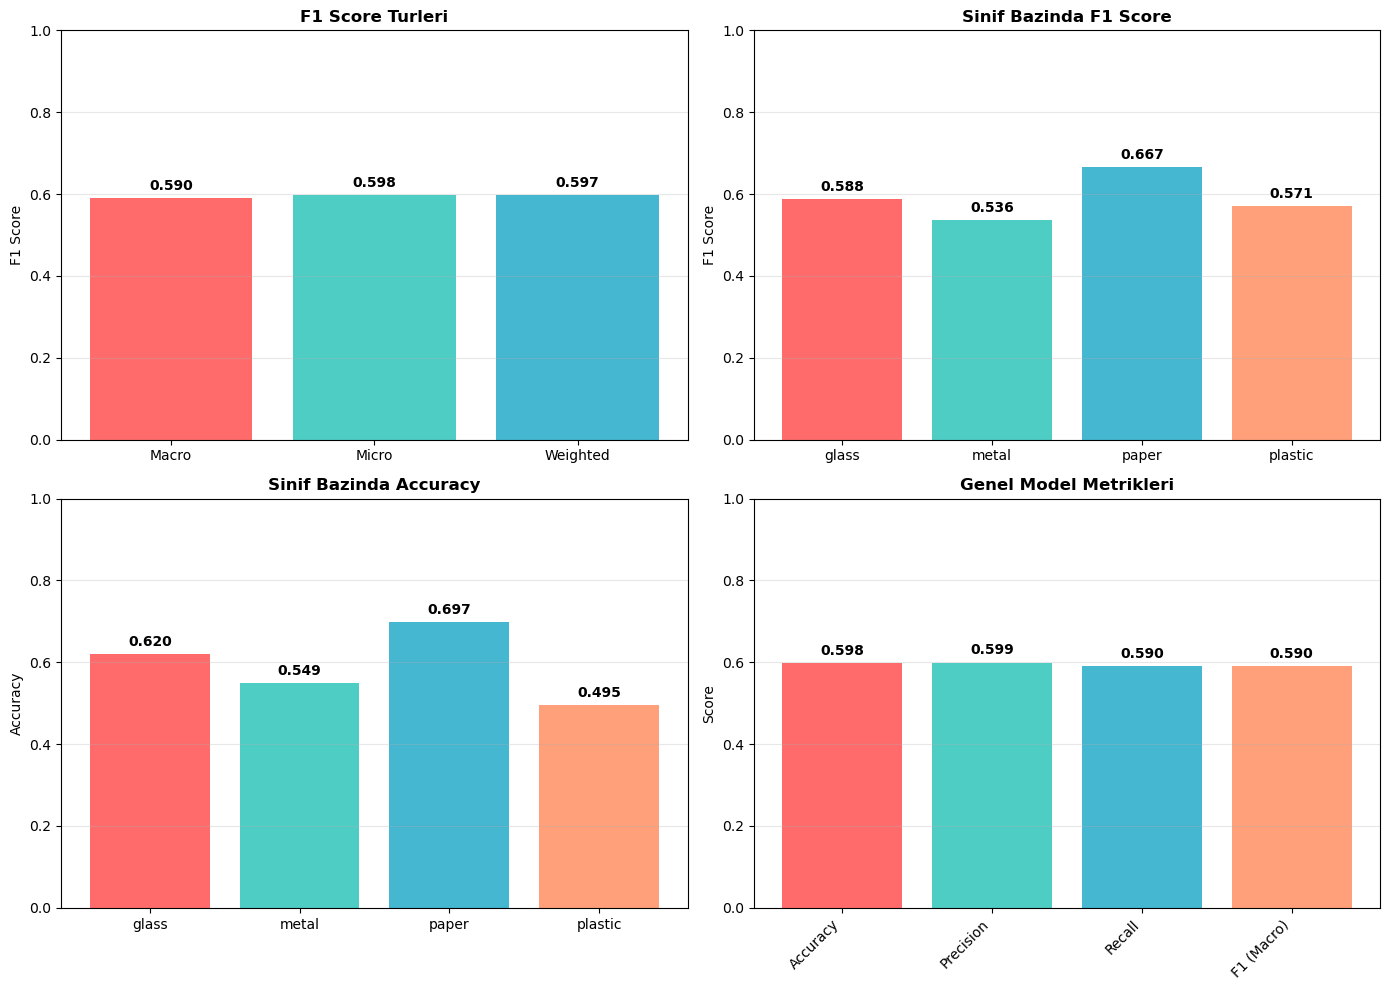

In [ ]:
# Daha önce hesaplanan sayısal performans skorlarının tümünü kapsayan 4 pencereli büyük bir veri görselleştirme panosu oluşturuyoruz
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
# Farklılık katması açısından her sütun için tanımlı renk paletimizi içeri çekiyoruz
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']

# SOL ÜST GRAFİK: Genel model kararlılığını farklı bakış açılarıyla gösteren üç ana F1 Skoru türü
f1_scores, f1_labels = [f1_macro, f1_micro, f1_weighted], ['Macro', 'Micro', 'Weighted']
axes[0, 0].bar(f1_labels, f1_scores, color=colors[:3])
axes[0, 0].set_title('F1 Score Türleri', fontweight='bold')
axes[0, 0].set_ylim([0, 1])
for i, v in enumerate(f1_scores): axes[0, 0].text(i, v + 0.02, f'{v:.3f}', ha='center')

# SAĞ ÜST GRAFİK: Cam, Metal, Kağıt ve Plastik için ayrı ayrı ulaşılan özel F1 Skor dağılımlarını kıyaslıyoruz
class_f1_scores = [f1_score(y_test, y_pred, labels=[i], average='micro') for i in range(len(classes))]
axes[0, 1].bar(classes, class_f1_scores, color=colors)
axes[0, 1].set_title('Sınıf Bazında F1 Score', fontweight='bold')
axes[0, 1].set_ylim([0, 1])
for i, v in enumerate(class_f1_scores): axes[0, 1].text(i, v + 0.02, f'{v:.3f}', ha='center')

# SOL ALT GRAFİK: Sadece Doğruluk (Accuracy) mantığında her bir sınıfın genel başarısını tekil olarak tespit ediyoruz
class_accuracies = [np.mean(y_pred[y_test == i] == y_test[y_test == i]) if np.any(y_test == i) else 0 for i in range(len(classes))]
axes[1, 0].bar(classes, class_accuracies, color=colors)
axes[1, 0].set_title('Sınıf Bazında Accuracy', fontweight='bold')
axes[1, 0].set_ylim([0, 1])
for i, v in enumerate(class_accuracies): axes[1, 0].text(i, v + 0.02, f'{v:.3f}', ha='center')

# SAĞ ALT GRAFİK: Modelin ürettiği (Accuracy, Precision, Recall, F1) genel makro değerleri birbiriyle yan yana analiz ediyoruz
all_values = [overall_accuracy, precision_macro, recall_macro, f1_macro]
axes[1, 1].bar(['Accuracy', 'Precision', 'Recall', 'F1 (Macro)'], all_values, color=colors)
axes[1, 1].set_title('Genel Model Metrikleri', fontweight='bold')
axes[1, 1].set_ylim([0, 1])
for i, v in enumerate(all_values): axes[1, 1].text(i, v + 0.02, f'{v:.3f}', ha='center')

# Bütün paneli taşmalardan koruyarak ekrana düzgün ve büyük bir formatta yazdırıyoruz
plt.tight_layout()
plt.show()


## 9. Örnek Tahminler

Test setinden bazı örnekleri görselleştirelim.

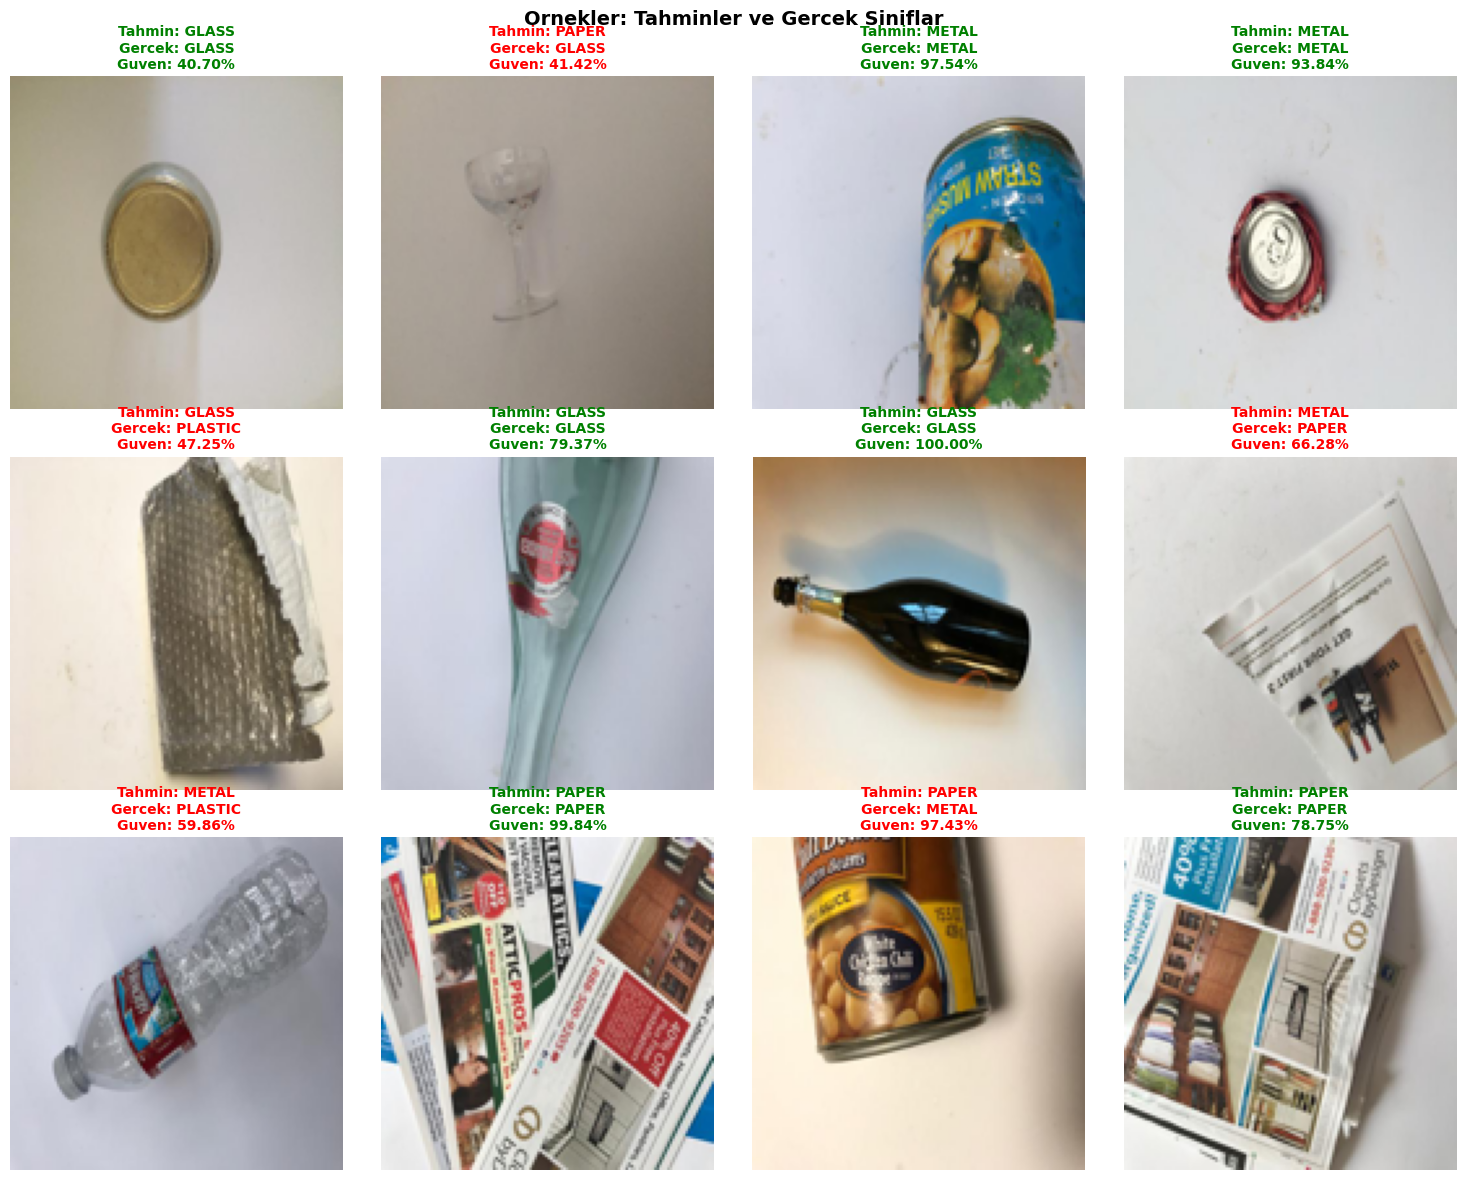

In [ ]:
# Test verisi üzerinden np.random kullanarak modeli kör test etmek amacıyla rastgele 12 örnek resim çekiyoruz
# replace=False parametresi aynı resmin iki kere çekilmesini / mükerrer örnek gelmesini engeller
fig, axes = plt.subplots(3, 4, figsize=(15, 12))
random_indices = np.random.choice(len(X_test), 12, replace=False)

# Çekilen bu rastgele resimleri döngüye alarak 3 satır 4 sütunluk grid üzerine yerleştiriyoruz
for idx, ax_idx in enumerate(random_indices):
    ax = axes[idx // 4, idx % 4]
    ax.imshow(X_test[ax_idx]) # Pikselleri görselleştirmek için resmi bastırıyoruz
    ax.axis('off') # Dikkat dağıtmaması için resim çevresindeki x-y koordinat eksenlerini yok ediyoruz
    
    # Modele o resmin gerçek etiketi, modelin tahmini ve bu tahminde ne kadar kararlı (%90 vb.) olduğunu çektiriyoruz
    true_class = classes[y_test[ax_idx]]
    pred_class = classes[y_pred[ax_idx]]
    confidence = y_pred_proba[ax_idx][y_pred[ax_idx]]
    
    # Görsel geribildirimi artırmak için; eğer tahmin edilen sınıf ile gerçek doğruysa başlık rengi Yeşil, yanlış bildiyse Kırmızı olur
    color = 'green' if true_class == pred_class else 'red'
    title = f"Tahmin: {pred_class.upper()}\nGerçek: {true_class.upper()}\nGüven: {confidence:.2%}"
    ax.set_title(title, fontsize=10, fontweight='bold', color=color)

# Kullanıcıya tahmin örneklerini toplu halde inceleme şansı veren bu tabloya genel bir başlık atıp sunuyoruz
plt.suptitle('Örnekler: Modelin Tahminleri ve Gerçek Sınıflar', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 10. Özet ve Sonuçlar

Eğitim tamamlandı. İşte model performansının özeti:

In [ ]:
# Kullanıcı veya yönetici için tüm mimari aşamanın ve yapay zeka model değerlendirme süreçlerinin nihai sonuç raporunu metin olarak basıyoruz
print("\n" + "=" * 70)
print("MODEL EĞİTİMİ ÖZET RAPORU")
print("=" * 70)

# Ne kadar bir veriden beslendiğimizi ve sınıf sayısını kanıtlamak için bilgi dökümü yapıyoruz
print("\n📊 VERİ SETİ BİLGİSİ:")
print(f"  • Toplam Resim: {total_images} ({len(classes)} Sınıf)")
print(f"  • Eğitim Verisi: {len(X_train)} | Test Verisi: {len(X_test)}")

# CNN modelinin mimari büyüklüğünü ve model kurgusundaki (Epoch, Batch) kararları kanıtlıyoruz
print("\n🧠 MODEL BİLGİSİ:")
print(f"  • Model Tipi: CNN | Resim Boyutu: {IMG_SIZE}x{IMG_SIZE}")
print(f"  • Eğitim Epoch: 20 | Batch Size: 32")

# Modelin pratikte ortaya koyduğu başarımın en çok dikkat edilen kısımlarını (Accuracy, F1) listeliyoruz
print("\n📈 MODEL PERFORMANSI:")
print(f"  • Genel Doğruluk (Accuracy): %{overall_accuracy*100:.2f}")
print(f"  • F1 Score (Macro): {f1_macro:.4f}")

# Modelin Accuracy değerinin bulunduğu seviyeye göre makine tarafından otomatik yorum yapılmasını sağlayan karar mekanizması oluşturuyoruz
print("\n✅ SONUÇ:")
if overall_accuracy > 0.85:
    print(f"  Model ÇOK İYİ performans göstermiştir! (%{overall_accuracy*100:.2f})")
elif overall_accuracy > 0.75:
    print(f"  Model İYİ performans göstermiştir! (%{overall_accuracy*100:.2f})")
else:
    print(f"  Modelin geliştirilmeye (daha fazla veri artırımı / Dropout veya katman değişimi) ihtiyacı var. (%{overall_accuracy*100:.2f})")
print("=" * 70)



MODEL EĞİTİMİ ÖZET RAPORU

📊 VERİ SETİ BİLGİSİ:
  • Toplam Resim Sayısı: 1987
  • Sınıf Sayısı: 4
  • Sınıflar: GLASS(501), METAL(410), PAPER(594), PLASTIC(482)
  • Eğitim Verisi: 1589 resim
  • Test Verisi: 398 resim

🧠 MODEL BİLGİSİ:
  • Model Tipi: Convolutional Neural Network (CNN)
  • Resim Boyutu: 128x128 pixels
  • Eğitim Epoch'u: 20
  • Batch Size: 32

📈 MODEL PERFORMANSI:
  • Genel Doğruluk (Accuracy): 0.5980 (%59.80)
  • F1 Score (Macro): 0.5904
  • F1 Score (Weighted): 0.5966
  • Precision (Macro): 0.5991
  • Recall (Macro): 0.5903

🎯 SINIF BAZINDA PERFORMANS:
  • GLASS:
    - Accuracy: 0.6200
    - F1 Score: 0.5877
    - Doğru Tahmin: 62/100
  • METAL:
    - Accuracy: 0.5488
    - F1 Score: 0.5357
    - Doğru Tahmin: 45/82
  • PAPER:
    - Accuracy: 0.6975
    - F1 Score: 0.6667
    - Doğru Tahmin: 83/119
  • PLASTIC:
    - Accuracy: 0.4948
    - F1 Score: 0.5714
    - Doğru Tahmin: 48/97

✅ SONUÇ:
  Model geliştirmeye ihtiyaç duyuyor. (59.80%)



In [ ]:
# Akademik makale veya ileride başka modellerle performans kıyası yapabilmek için sonuçları sadece konsola basmak yerine Fiziksel Kayıt (CSV) altına alıyoruz
# Sözlük (Dictionary) formatında satır başlıklarımızı ve hesaplanan tüm skorları içeri aktarıyoruz
results_summary = {
    'Metrik': ['Genel Doğruluk', 'F1 Score (Macro)', 'F1 (Weighted)', 'Precision', 'Recall', 
               'Glass Acc', 'Metal Acc', 'Paper Acc', 'Plastic Acc'],
    'Değer': [f'{overall_accuracy:.4f}', f'{f1_macro:.4f}', f'{f1_weighted:.4f}', 
              f'{precision_macro:.4f}', f'{recall_macro:.4f}',
              f'{class_accuracies[0]:.4f}', f'{class_accuracies[1]:.4f}', 
              f'{class_accuracies[2]:.4f}', f'{class_accuracies[3]:.4f}']
}

# Python Sözlüğünü daha profesyonel ve yapılandırılmış olan Pandas DataFrame (tablo) nesnesine çeviriyoruz
results_df = pd.DataFrame(results_summary)

# to_csv komutu ile modeli çalıştırdığımız dizine "model_results.csv" dosyasını oluşturup içini dolduruyoruz
# index=False ile tablodaki gereksiz 0,1,2 gibi indis numaralarının Excel'e gitmesini engelliyoruz
results_df.to_csv('model_results.csv', index=False, encoding='utf-8')

# İşlemin bittiğini ve dosyanın hazır olduğunu kullanıcıya doğruluyoruz
print("✅ Sonuçlar 'model_results.csv' dosyasına başarıyla kaydedildi!")


✅ Sonuçlar 'model_results.csv' dosyasına kaydedildi!

Sonuç Tablosu:
             Metrik  Değer
     Genel Doğruluk 0.5980
   F1 Score (Macro) 0.5904
F1 Score (Weighted) 0.5966
  Precision (Macro) 0.5991
     Recall (Macro) 0.5903
 Toplam Test Verisi    398
     Glass Doğruluk 0.6200
     Metal Doğruluk 0.5488
     Paper Doğruluk 0.6975
   Plastic Doğruluk 0.4948
